# **Analisis variables - Géneros**

# Bibliotecas

In [1]:
#Carga de datos
import pandas as pd
import json
import numpy as np
from Server_PD import download_dataframe_minio

from collections import Counter
import re

#Graficas
import seaborn as sns
import matplotlib.pyplot as plt
import isodate

from itertools import combinations
import ast




# Carga de datos

In [2]:
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]
df = download_dataframe_minio("pd1", "grupo1/clean/union_dfs_20260305",claves=claves,file_format="parquet")
df.tail()

,ID,Titulo,Descripcion,Visualizaciones,Tags,Duracion,Fecha_publicacion,Titulo_canal,Subtitulos,Generos,Subgeneros,Made for kids,Rango_edad
13704,ulzTXwihC_g,The Inmate Teaching Finance Behind Bars,Curtis Carroll is simply known as “Wall Street...,321679,"great big story, gbs, lag, documentary, docs, ...",PT3M55S,2018-07-03 06:00:05+00:00,Great Big Story,Kind: captions Language: en (melodic piano mus...,People & Blogs,Society,False,5-8
13705,W6CBb3yX9Zs,How Is Your Phone Changing You?,Should you be worried about your cellphone?\n6...,5905697,"Science, AsapSCIENCE, Phone, Smartphone, Cellp...",PT3M12S,2016-06-02 16:06:03+00:00,AsapSCIENCE,Kind: captions Language: en of the 7 billion p...,Science & Technology,Technology,False,5-8
13706,VFJMnuEZ4sk,POV me coming back to school after summer brea...,,313163,,PT18S,2025-08-14 21:02:00+00:00,My PB and J,None,People & Blogs,"Entertainment, Humour",False,5-8
13707,7UXd2z0yg1o,Everything I Ate On BULLET TRAINS in JAPAN for...,Experience a Japanese bullet train (or Shinkan...,6846267,"jeanelle eats, janelle eats, food and travel, ...",PT19M46S,2024-03-10 14:00:11+00:00,Jeanelleats,Kind: captions Language: en let's hop on 10 bu...,People & Blogs,"Food, Lifestyle (sociology)",False,5-8
13708,bS1xGetyrh0,How is the NFL Schedule Created? | NFL Explained,Subscribe to NFL Network: http://goo.gl/4GOLwY...,826799,"nfl, nfl network, football, american football",PT21M2S,2021-05-13 00:00:14+00:00,NFL,None,Sports,"American football, Sport",False,5-8


# Transformamos la columna "Duracion"

In [3]:

def iso_a_minutos(iso_duration):
    """"
    Funcion que convierte la duracion a minutos
    """
    try:
        duracion = isodate.parse_duration(iso_duration)
        return duracion.total_seconds() / 60
    except:
        return 0

df['Duracion'] = df['Duracion'].apply(iso_a_minutos)

# Limpiamos los datos

- Igualamos el formato. 
- Quitamos caracteres extraños. 
- Separamos los generos que están juntos para tratarlos individualmente. 
- Eliminamos nulos y duplicados.

In [4]:
"""
Limpieza de datos
"""
def limpieza_final(dato):
    
    limpio = str(dato).replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    
    partes = limpio.split(',')
    
    resultado = []
    for p in partes:
        nombre = re.sub(r'\(.*\)', '', p).strip() 
        if nombre and nombre.lower() != 'none':
            resultado.append(nombre.capitalize())
            
    return list(set(resultado)) 

df['Generos'] = df['Generos'].apply(limpieza_final)

#Filtramos los videos que no tienen genero asignado
df = df[df['Generos'].apply(len) > 0].copy()



# Top 20 géneros mas frecuentes

C:\Users\javil\AppData\Local\Temp\ipykernel_2820\3089516639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')


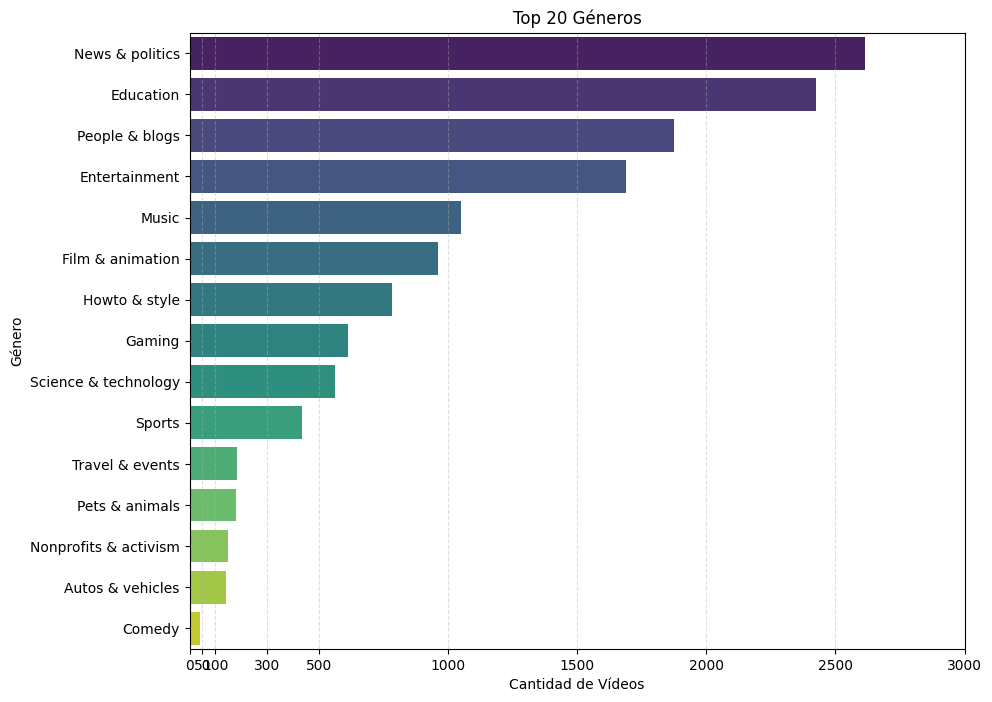

In [5]:
"""
Grafica que muestra los top 20 generos mas frecuentes
"""
top_20 = df['Generos'].explode().value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')

# Ticks
max_frecuencia = top_20.max()

tus_ticks = [0, 50, 100, 300, 500]

paso_automatico = 200 if max_frecuencia < 2000 else 500
ticks_automaticos = list(range(0, int(max_frecuencia) + paso_automatico, paso_automatico))

ticks_finales = sorted(list(set(tus_ticks + ticks_automaticos)))

plt.xticks(ticks_finales)

#Detalles
plt.title("Top 20 Géneros")
plt.xlabel("Cantidad de Vídeos")
plt.ylabel("Género")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

La gráfica muestra un dominio de dos categorías que superan los 2000 vídeos.
'Society' y 'Lifestyle'. Esto indica que la mayor parte del contenido de nuestra base de datos se basa en personas, opinión o hechos sociales.

Observamos tambien categorías muy cercanas 
Podemos apreciar como los generos mas comunes son muy generales. Pueden abarcar muchos temas distintos. A medida que vamos bajando en el numero de videos, vemos como son temas mas especificos que se podrían tratar como subcategorías. Por ejemplo. 'Role-playing videogame' podria estar dentro de la categoria de videojuegos.
Además hay categorías que se podrian considerar cercanas como 'Television program' y 'Film', o 'Society' y 'Politics'. Muchos vídeos podrían pertenecer a ambos, por ello utilizaremos de listas de géneros además de una etiqueta única y general (clasificación multietiqueta).

De esta forma podriamos usar esta informacion para definir cuales serán los generos que asignaremos como principales (los estén al principio de la grafica) y cuales tomaremos como subcategorías (los menos frecuentes).

# Gráfico de correlacion 

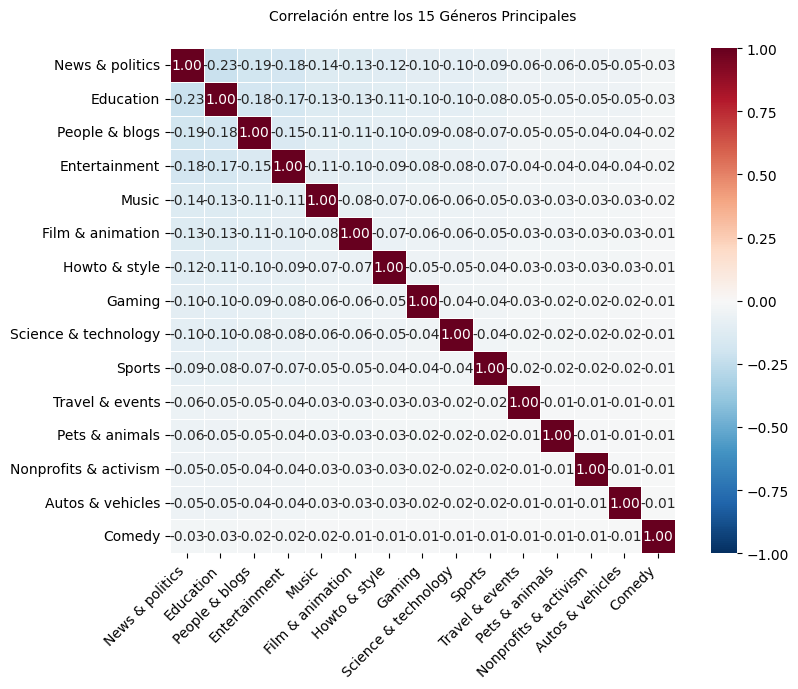

In [6]:

# Convertimos la lista de géneros en columnas (One-Hot Encoding)
# Tabla que me dice 1 si el video tiene el genero, 0 si no
df_dummies = df['Generos'].explode().str.get_dummies().groupby(level=0).sum()

# Usamos el top 15 para que sea legible
top_15_nombres = df['Generos'].explode().value_counts().head(15).index
df_top = df_dummies[top_15_nombres]

# Matriz correlacion
matriz_corr = df_top.corr()

# Configuración del Heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_corr, 
    annot=True,
    fmt='.2f',            
    cmap="RdBu_r",        
    center=0,             
    vmin=-1, vmax=1,      
    linewidths=.5,        
    square=True          
)

plt.title("Correlación entre los 15 Géneros Principales", fontsize=10, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Lo primero que vemos al observar el clustermap es que hay una fuerte correlacion entre 'Film' 'Entertainment' y entre 'Society' y 'Politics'. Esto indica que casi todos los vídeos de política se etiquetan también como sociedad y los de cine como entretenimiento. Por ejemplo, si el modelo predice "Politics", es casi seguro que acertará "Society". Esto facilita la clasificación pero también indica que las fronteras entre estos géneros son difusas.

Nos encontramos también con categorias solitarias. Por ejemplo, 'Religion'. Estas serán las más fáciles de aislar y clasificar correctamente, ya que no comparten rasgos con el resto.

Podemos objservar otros casos donde hay correlacion entre categorias donde existe una relación de jerarquía. Este es el caso de 'Music' y 'Pop music'. 'Pop music' es una subcategoría de 'Music'.

Hay géneros que rara vez aparecen juntos. Es poco probable ver un vídeo que sea simultáneamente 'Video game culture' y 'Politics'. Podemos usar esto como una regla de descarte. Si detecta keywords de videojuegos, puede bajar drásticamente la probabilidad de que el vídeo sea de política.

In [7]:
#Creamos un diccionario con df's de filtrando 6 generos mas frecuentes
top_6 = df['Generos'].explode().value_counts().head(6).index.tolist()
dfs_generos = {}
nombres = []
for genero in top_6 :
    nombre_df = f"{genero.lower().replace(' ', '_')}"
    nombres.append(nombre_df)
    dfs_generos[nombre_df] = df[df['Generos'].apply(lambda x: genero in x)].copy()

print("Los df's con los que vamos a trabajar son:")
for nombre in nombres:
    print(nombre)


Los df's con los que vamos a trabajar son:
news_&_politics
education
people_&_blogs
entertainment
music
film_&_animation


# Keywords


In [ ]:

# Lista extendida de stopwords en inglés
stopwords_en = {
    # Tus originales
    'the', 'and', 'a', 'to', 'of', 'in', 'is', 'it', 'you', 'that', 'he', 'was', 'for', 'on', 'are', 
    'with', 'as', 'i', 'his', 'they', 'be', 'at', 'one', 'have', 'this', 'from', 'or', 'had', 'by', 
    'hot', 'word', 'but', 'what', 'some', 'we', 'can', 'out', 'other', 'were', 'all', 'there', 
    'when', 'up', 'use', 'your', 'how', 'said', 'an', 'each', 'she', 'which', 'do', 'their', 
    'if', 'will', 'about', 'many', 'then', 'them', 'these', 'so', 'her', 'would', 'make', 
    'like', 'him', 'into', 'time', 'has', 'look', 'two', 'more', 'write', 'go', 'see', 
    'number', 'no', 'way', 'could', 'people', 'my', 'than', 'first', 'water', 'been', 
    'called', 'who', 'am', 'its', 'now', 'find', 'get', 'none', 'full', 'nbsp',
    'because', 'because', 'so', 'yet', 'unless', 'while', 'although', 'since', 'also',
    'just', 'very', 'really', 'even', 'still', 'maybe', 'actually', 'well', 'too', 'only',
    'never', 'always', 'sometimes', 'ever', 'again', 'back', 'here', 'there', 'where',
    'know', 'think', 'want', 'take', 'tell', 'come', 'give', 'mean', 'need', 'should',
    'right', 'let', 'may', 'must', 'keep', 'put', 'seem', 'look', 'much', 'many',
    'me', 'us', 'our', 'mine', 'ours', 'yourself', 'something', 'anything', 'everything',
    'another', 'every', 'own', 'same', 'such', 'very', 'next', 'right', 'okay', 'why', 'here'
    'not', 'yeah', 'kind', 'going', 'today', 'those', 'good', 'thank'
}


def obtener_keywords_en(columna, top_n=20):
    """"
    Funcion que devuelve el top n de palabras más comunes de un columna (título o subtitulos)
    """
    todas_las_palabras = []
    
    for texto in columna:
        texto_limpio = str(texto).lower()
        # Solo extraemos letras
        palabras = re.findall(r'[a-z]+', texto_limpio)
        
        # Filtrar por longitud y stopwords
        palabras_filtradas = [p for p in palabras if p not in stopwords_en and len(p) > 3]
        todas_las_palabras.extend(palabras_filtradas)
    
    return Counter(todas_las_palabras).most_common(top_n)



In [ ]:

def graficar_palabras_comunes(df, columna, titulo_grafica, ax_obj, color):
    
    """"
    Funcion que genera un barplot de las top 10 palabras más comunes del título por cada grupo. 
    """

    keywords = obtener_keywords_en(df[columna], top_n=10)
    
    if not keywords:
        ax_obj.set_title(f"{titulo_grafica} (Sin datos)")
        return 

    # Desempaquetamos los resultados
    palabras_lista, conteos = zip(*keywords)
    
    # Dibujar grafica
    sns.barplot(x=list(conteos), y=list(palabras_lista), ax=ax_obj, color=color)
    ax_obj.set_title(titulo_grafica)
    ax_obj.set_xlabel('Frecuencia')
    ax_obj.set_ylabel('Palabra')

**TÍTULO**

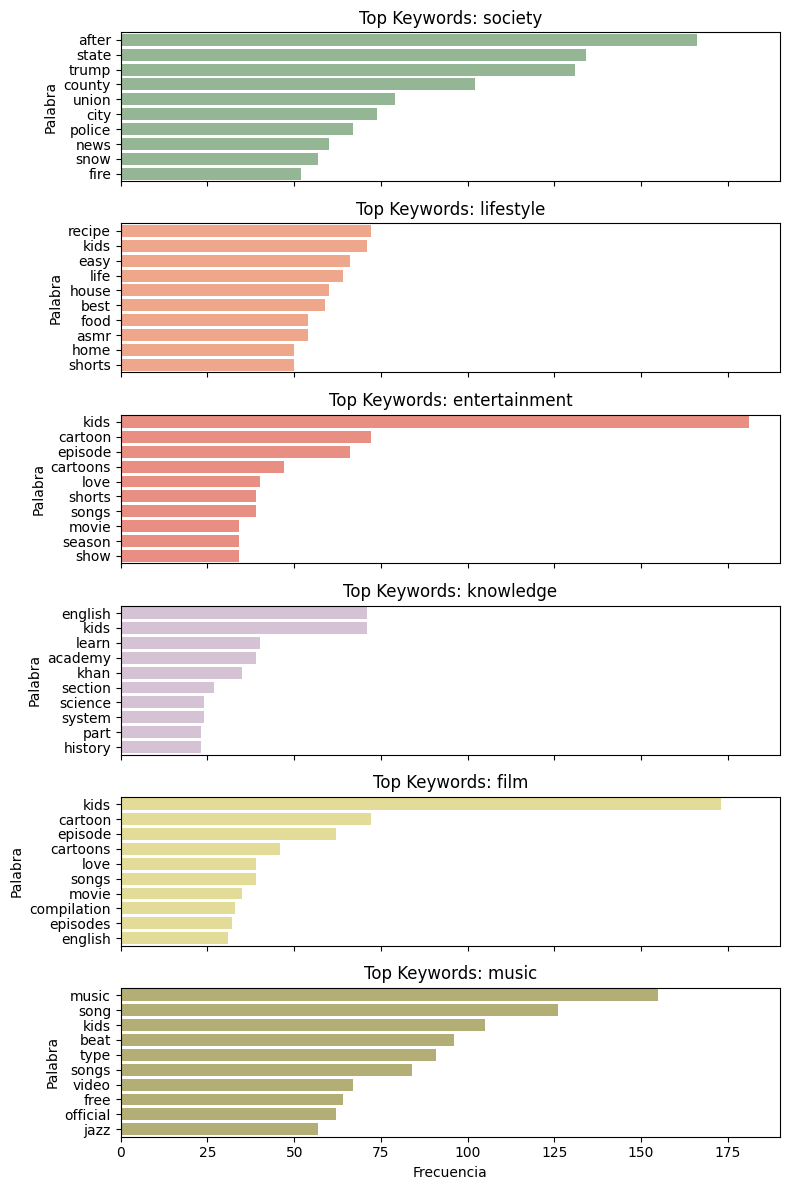

In [ ]:
#Palabras más comunes en títulos
fig, ax = plt.subplots(6, 1, figsize=(8, 12), sharex=True)

colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki']

for i, nombre, color in zip(range(0, 6), nombres, colores):
    graficar_palabras_comunes(dfs_generos[nombre], 'Titulo', f'Top Keywords: {nombre}', ax[i], color)    

plt.tight_layout()
plt.show()


Generos como 'Music' y 'Society' presentan palabras clave muy descriptivas. Por ejemplo en 'Music' encontramos palabras como 'song', 'beat', 'official', 'jazz' que definen el contenido del video de manera muy descriptiva. En Society, palabras como 'Police', 'Trump' o 'News' actúan como indicadores claros. 
Para el modelo, estas categorías serán más fáciles de clasificar mediante técnicas de procesamiento de lenguaje natural.

Encontramos un solapamiento entre 'Film' y 'Entertainment'
Ambos géneros comparten términos más genéricos como 'songs', 'cartoons', 'episode', 'love' o 'kids'.
Esto confirma lo que aparece en el Heatmap, son categorías más difusas. El modelo necesitará algo más que palabras sueltas para distinguir entre un vídeo de entretenimiento y uno de cine.

Se aprecia la existencia de nombres propios (por ejemplo, 'Trump') o eventos globales dominan ciertos géneros. Esto puede suponer un riesgo ya que si entrenamos el modelo hoy, aprenderá que la política es igual a 'Trump'. Esto es un sesgo temporal. 


**SUBTÍTULOS**

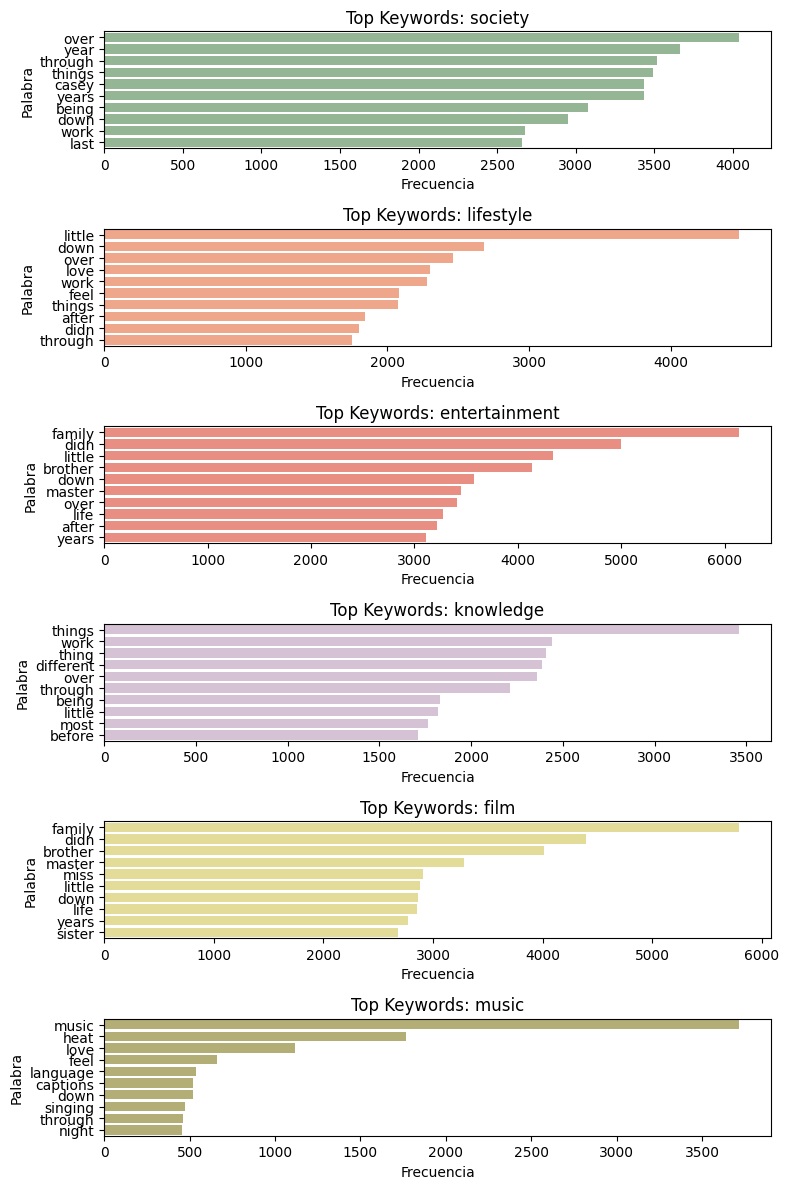

In [ ]:
#Palabras más comunes en subtítulos
fig, ax = plt.subplots(6, 1, figsize=(8, 12))

colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki']

for i, nombre, color in zip(range(0, 6), nombres, colores):
    graficar_palabras_comunes(dfs_generos[nombre], 'Subtitulos', f'Top Keywords: {nombre}', ax[i], color)    

plt.tight_layout()
plt.show()

# Densidad de habla

In [ ]:
def calcular_wpm(row):

    """"
    Función que devuelve el numero de palabras por minuto de un vídeo. (Numero total de palabras /
    duración total del vídeo)
    """
    
    # Convertimos a string y  limpiamos nulos
    sub_texto = str(row['Subtitulos'])
    if sub_texto == "None" or sub_texto == "nan" or row['Duracion'] == 0:
        return 0
    
    numero_palabras = len(sub_texto.split())
    return numero_palabras / row['Duracion']

In [ ]:
for nombre in nombres:
    dfs_generos[nombre]['Palabras_Por_Minuto'] = dfs_generos[nombre].apply(calcular_wpm, axis=1)
    dfs_generos[nombre]['Palabras_Por_Minuto'] = round(dfs_generos[nombre]['Palabras_Por_Minuto'], 2)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_35680\2758300401.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_comparativa_generos, palette='Set2')


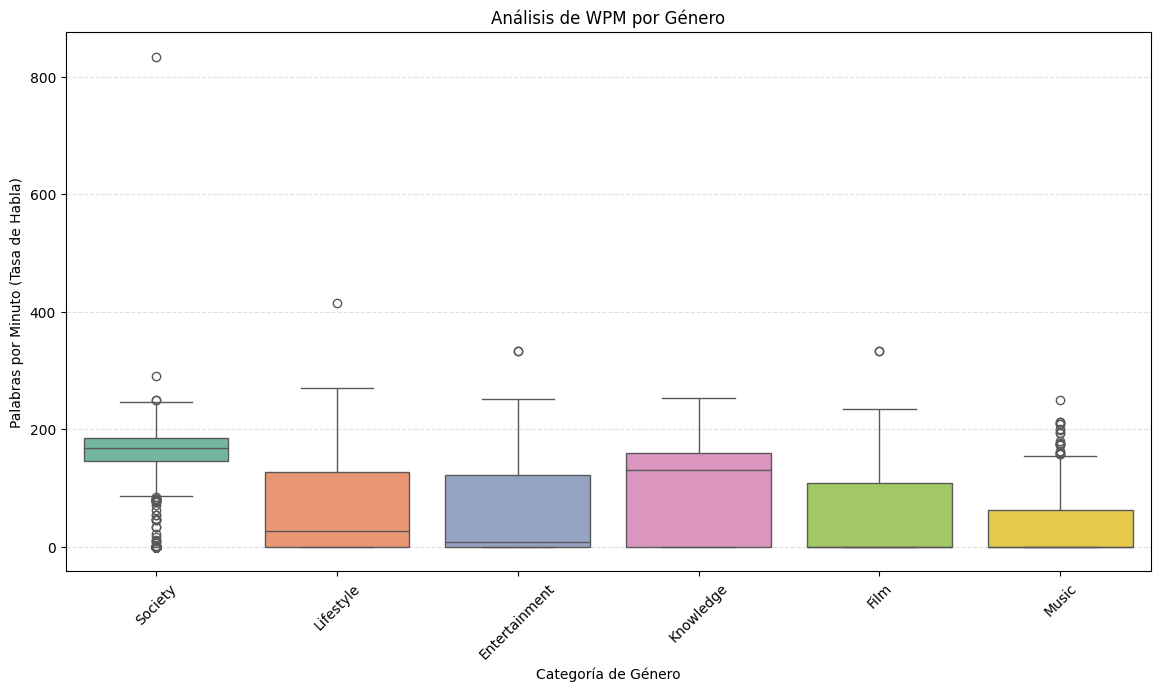

In [ ]:
df_comparativa_generos = pd.concat([
    dfs_generos[nombre].assign(Genero=nombre.replace('df_', '').capitalize()) 
    for nombre in nombres
])

plt.figure(figsize=(14, 7))

sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_comparativa_generos, palette='Set2')

plt.title('Análisis de WPM por Género')
plt.xlabel('Categoría de Género')
plt.ylabel('Palabras por Minuto (Tasa de Habla)')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [ ]:
print("Valores máximos de WPM detectados por género:")
print(df_wpm_generos.groupby('Genero')['Palabras_Por_Minuto'].max().sort_values(ascending=False))

Valores máximos de WPM detectados por género:
Genero
Society          834.00
Lifestyle        414.78
Film             333.32
Entertainment    333.32
Knowledge        253.05
Music            250.15
Name: Palabras_Por_Minuto, dtype: float64


'Society' es el género con mayor densidad verbal y consistencia, presentando una mediana elevada y un rango intercuartílico estrecho en comparación con los demás. Esto puede estar justificado por que los videos son mas cortos de lo usual. Presenta outlier extremos.

'Knowledge' uestra una de las medianas más altas después de Sociedad, lo que valida que son vídeos con una carga informativa y narrativa superior.

'Music' y 'Entertainment' presentan las medianas de WPM más bajas. En el caso de Entretenimiento, la caja está muy desplazada hacia el cero, lo que indica una predominancia de contenido visual sobre el verbal.

'Lifestyle' y 'Film' muestran una gran dispersión (bigotes largos), lo que indica que conviven vídeos muy ruidosos con otros de ritmo pausado.


# Duración

C:\Users\Usuario\AppData\Local\Temp\ipykernel_35680\1610622532.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genero', y='Duracion', data=df_comparativa_generos, palette='Set3')


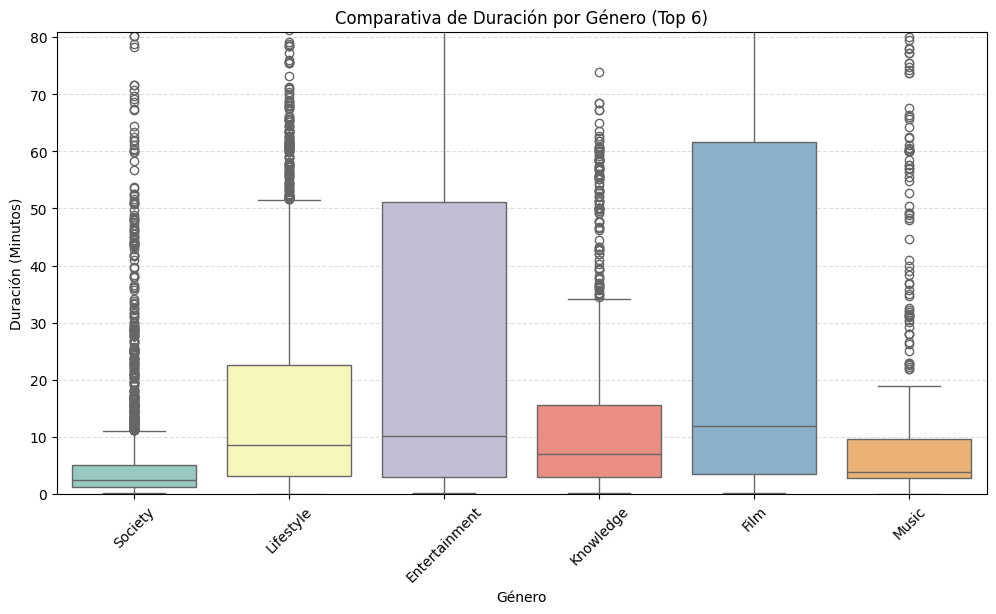

In [ ]:

plt.figure(figsize=(12, 6))

# Boxplot
sns.boxplot(x='Genero', y='Duracion', data=df_comparativa_generos, palette='Set3')

# Zoom
limite_superior = df_comparativa_generos['Duracion'].quantile(0.95) * 0.8
plt.ylim(0, limite_superior)

# Detalles
plt.title('Comparativa de Duración por Género (Top 6)')
plt.xlabel('Género')
plt.ylabel('Duración (Minutos)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

Entre los géneros de alta variabilidad tenemos 'Entertainment' y 'Film' presentan las cajas más grandes y bigotes que se extienden notablemente, indicando que no tienen una duración estandarizada y pueden contener desde clips cortos hasta largometrajes. Se confirma la relación Entertainment-Film.

Entre los géneros más compactos están 'Society' y 'Music', que muestran una concentración masiva en duraciones cortas (mediana inferior a 5-10 minutos). En Society, la enorme cantidad de outliers sugiere que, aunque la mayoría son clips breves, existe un volumen constante de vídeos extensos que nuestro modelo va a tener aprender a gestionar.


# Duración (Extra)

In [ ]:
def graficar_histograma_duracion(df, titulo, ax_obj, color):
    """"
    Funcion que genera un histograma comparativo de la duración de los vídeos
    """
    limite_sugerido = df['Duracion'].quantile(0.98)
    limite_final = int(np.ceil(limite_sugerido / 5) * 5)
    limite_final = max(min(limite_final, 90), 15)

    sns.histplot(df['Duracion'], bins=limite_final, kde=True, color=color, ax=ax_obj, edgecolor='white', alpha=0.7)
    
    ax_obj.set_title(titulo)
    ax_obj.set_xlabel('Minutos')
    ax_obj.set_ylabel('Cantidad de Vídeos')
    
    ax_obj.set_xlim(0, limite_final)

    ticks = np.arange(0, limite_final + 1, 5)
    ax_obj.set_xticks(ticks)
    ax_obj.set_xticklabels([f"{int(t)}" for t in ticks])

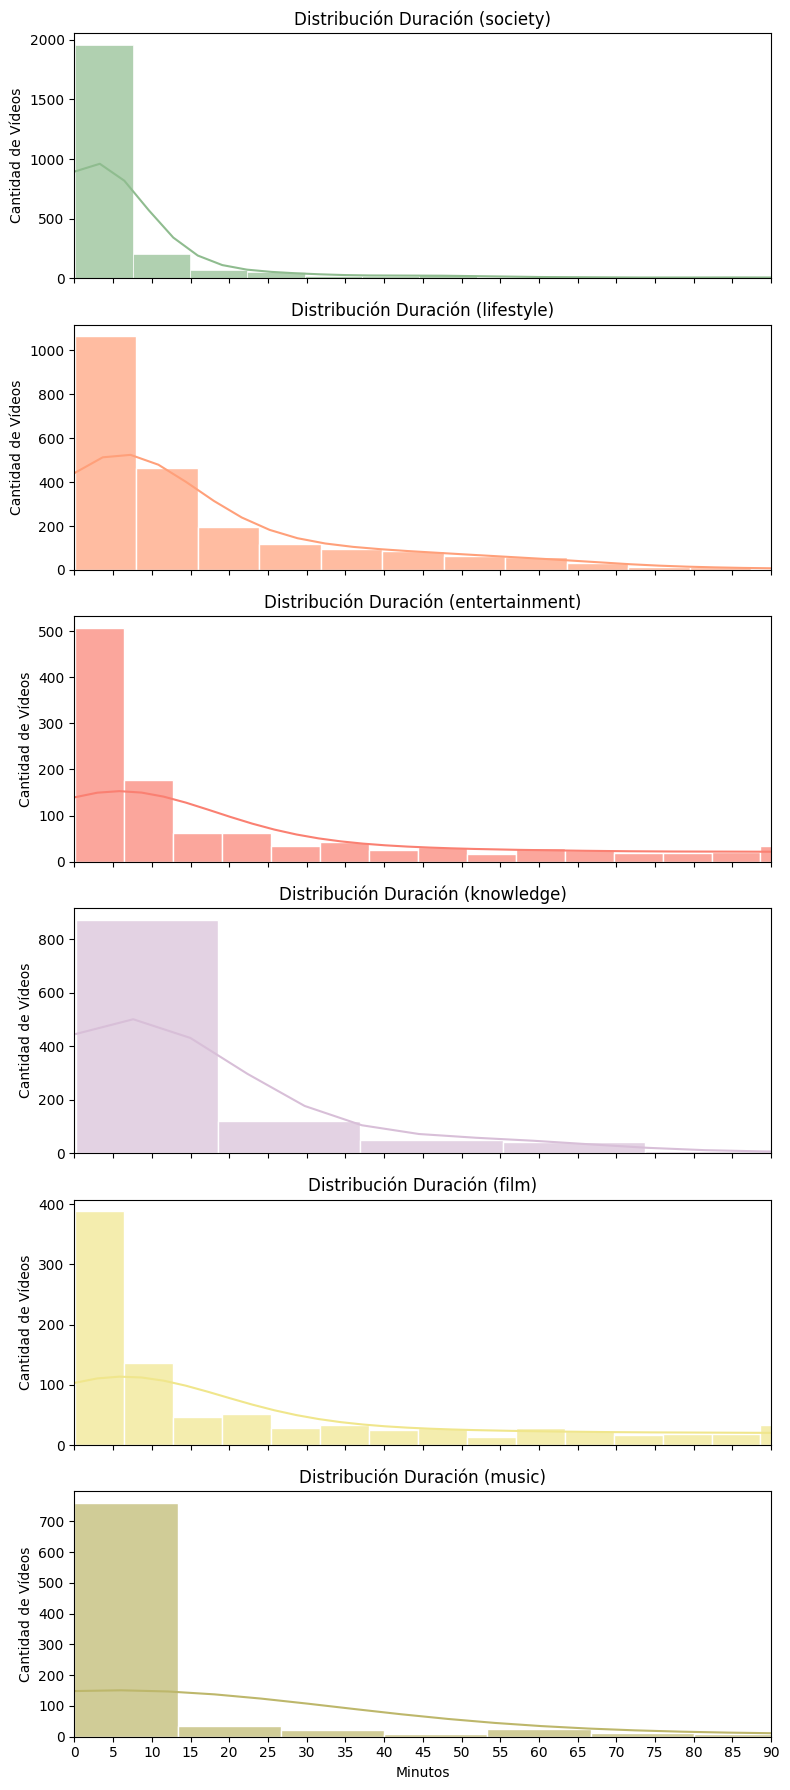

In [ ]:

# Configuración
fig, ax = plt.subplots(6, 1, figsize=(8,18), sharex=True)

colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki']

for i, nombre, color in zip(range(0, 6), nombres, colores):
    graficar_histograma_duracion(dfs_generos[nombre], f'Distribución Duración ({nombre})', ax[i], color)

plt.tight_layout()
plt.show()